# 1_02 — Exopeptidases: a ladder of truncations, not a single cut

## Scope

Eleven of the 57 panel proteases are exopeptidases. They are usually lumped
with endopeptidases as "degradation", and for a time-course model that is
wrong in three separate ways. This notebook measures how wrong, so that the
aggregation in `4_` can treat them correctly.

## The biology the model has to respect

An **endopeptidase** hydrolyses an internal bond. One molecule becomes two, and
both products carry new free termini, which makes them substrates for
exopeptidases in turn.

An **aminopeptidase** removes a single residue from the free α-amino terminus.
The product again has a free N-terminus, so the enzyme attacks it again: the
molecule descends a ladder of lengths rather than undergoing one event. Each
rung has its own rate, set by the residue newly exposed at the terminus, so the
ladder can stall when an unfavourable residue arrives. A blocked N-terminus,
acetylated or pyroglutamyl, makes the peptide resistant outright.

A **dipeptidyl-peptidase** removes an N-terminal dipeptide, and the DPP4 family
requires proline or alanine in the second position. This makes it
**self-limiting**: after removing Xaa-Pro it can continue only if the newly
second residue is again proline or alanine. In an arbitrary sequence that is
uncommon, so one or two rounds is the expected behaviour rather than processive
digestion.

A **tripeptidyl-peptidase** removes three residues. It shares the EC
sub-subclass of the dipeptidyl enzymes and is separated here by EC number,
because releasing three residues is a different transition.

A **peptidyl-dipeptidase**, which is what the two ACE units are, removes a
dipeptide from the **C-terminus** and requires a free carboxyl group. A
C-terminally amidated peptide is resistant, and amidation is common among
antimicrobial peptides.

## Why this changes activity and not only the event count

1. An internal cut can destroy an amphipathic helix in one event. Losing one or
   two terminal residues usually does not, so events are not equivalent in
   consequence.
2. Trimming can **raise** activity. The control panel records LL-37 processed
   by KLK5 and KLK7 into RK-31, KS-30 and KR-20, all of which retain
   antimicrobial activity. That is processing, not inactivation.
3. Every rung of a truncation ladder is a contiguous fragment, so its predicted
   MIC is already in the precomputed fragment table and needs no new inference.

## Questions

1. How far does the ladder descend before the rate collapses?
2. How does the per-rung rate evolve as the terminus changes?
3. What does each rung cost in activity?
4. Is trimming competitive with a single internal cut, or is it background?

## Execution contract

**Inputs:** `results/2_07_model_panel.csv`; `data/merops/34_homo_sapiens/matrices_logprob.npy`; `data/reference/human_proteome/composition.json`; `data/peptides_data/peptides_mic/peptides_apex.csv`; `data/peptides_data/peptides_mic/dbaasp_fragments_mic.csv`.

**Outputs:** `results/1_02_exopeptidase_processivity.csv`.

**Depends on:** `2_07` (a later notebook; the saved panel must already exist).

**Boundary:** A predicted MIC change for a fragment is not a measured serum degradation trajectory.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    allowed_cut_positions,
    load_amino_acid_background,
    load_protease_panel,
    masked_window_score,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
MIC_COLUMN = "A. baumannii ATCC 19606"
FRAGMENT_MIC_COLUMN = f"mic_{MIC_COLUMN}"
N_PROBE_PEPTIDES = 400
MIN_FRAGMENT_LENGTH = 4
SEED = 20260920

In [3]:
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
exopeptidases = panel.query(
    "event_geometry not in ['endopeptidase', 'unknown', 'non_hydrolase']"
).copy()
print(f"panel: {len(panel)} proteases | exopeptidases: {len(exopeptidases)}")
print(exopeptidases["event_geometry"].value_counts().to_string())

panel: 57 proteases | exopeptidases: 11
event_geometry
dipeptidyl_peptidase     6
peptidyl_dipeptidase     2
dipeptidase              1
aminopeptidase           1
tripeptidyl_peptidase    1


## Loading the matrices and the peptide probe

The matrices come from the human MEROPS dataset. The probe is a fixed sample of
DBAASP peptides, and every truncation of one of them is a contiguous fragment,
so its predicted MIC is looked up rather than recomputed.

In [4]:
human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = human_panel.matrices.numpy().astype(np.float64)  # (N, P, A)
matrix_of = {code: matrices[index] for index, code in enumerate(human_panel.codes)}

probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset", MIC_COLUMN])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
    .sample(n=N_PROBE_PEPTIDES, random_state=SEED)
    .reset_index(drop=True)
)
fragment_mic = pd.read_csv(
    common.DBAASP_FRAGMENTS_CSV, usecols=["fragment_sequence", FRAGMENT_MIC_COLUMN]
)
mic_of = dict(zip(fragment_mic["fragment_sequence"], fragment_mic[FRAGMENT_MIC_COLUMN]))

print(f"probe peptides: {len(probe)} (lengths {probe['sequence'].str.len().min()}"
      f"-{probe['sequence'].str.len().max()})")
print(f"fragment MIC lookup: {len(mic_of):,} sequences")
covered = probe["sequence"].isin(mic_of).mean()
print(f"probe peptides present in the fragment table: {covered:.1%}")

probe peptides: 400 (lengths 10-25)
fragment MIC lookup: 211,041 sequences
probe peptides present in the fragment table: 100.0%


## Descending the ladder

For each peptide and each exopeptidase the truncation is applied repeatedly. At
every rung the score of the single admissible bond is recomputed against the
**new** terminus, which is what makes the rate change as the ladder descends.

The ladder is enumerated to its geometric end, not to where the enzyme would
stop. Every rung is geometrically available; what limits the descent is the
**rate** of each step, and that rate is what is measured here. A ladder whose
score collapses after one rung is self-limiting even though its later rungs
exist on paper.

In [5]:
def descend_ladder(
    sequence: str, matrix: np.ndarray, geometry: EventGeometry, max_rungs: int = 12
) -> list[dict[str, object]]:
    """Trim a peptide repeatedly and record each rung.

    :param sequence: Starting peptide.
    :param matrix: Specificity matrix of the exopeptidase, shape ``(P, A)``.
    :param geometry: Event geometry, which fixes the admissible bond and the
        number of residues released.
    :param max_rungs: Guard on the ladder depth.
    :return: One record per rung, with the score of the bond attacked and the
        remaining fragment.
    """

    rungs: list[dict[str, object]] = []
    current = sequence
    for rung in range(1, max_rungs + 1):
        if len(current) <= MIN_FRAGMENT_LENGTH:
            break
        admissible = np.flatnonzero(allowed_cut_positions(len(current), geometry))
        if admissible.size == 0:
            break
        bond = int(admissible[0])
        score, observed = masked_window_score(current, bond, matrix, background=human_background)

        ## The released piece is whichever side the mechanism removes.
        if geometry in {
            EventGeometry.AMINOPEPTIDASE,
            EventGeometry.DIPEPTIDYL_PEPTIDASE,
            EventGeometry.TRIPEPTIDYL_PEPTIDASE,
        }:
            remaining = current[bond + 1 :]
        else:
            remaining = current[: bond + 1]

        rungs.append(
            {
                "rung": rung,
                "attacked": current,
                "remaining": remaining,
                "remaining_length": len(remaining),
                "score": score,
                "observed_subsites": observed,
                "released_residues": len(current) - len(remaining),
            }
        )
        current = remaining
    return rungs


records = []
for _, protease in exopeptidases.iterrows():
    matrix = matrix_of.get(protease["merops_code"])
    if matrix is None:
        continue
    geometry = EventGeometry(protease["event_geometry"])
    if geometry is EventGeometry.DIPEPTIDASE:
        ## A dipeptidase acts only on a free dipeptide, which is the end of a
        ## ladder rather than a step on one.
        continue
    for _, peptide in probe.iterrows():
        parent_mic = float(peptide[MIC_COLUMN])
        for rung in descend_ladder(peptide["sequence"], matrix, geometry):
            remaining_mic = mic_of.get(rung["remaining"])
            records.append(
                {
                    "merops_code": protease["merops_code"],
                    "name": protease["name"],
                    "event_geometry": protease["event_geometry"],
                    "parent": peptide["sequence"],
                    "parent_length": len(peptide["sequence"]),
                    "parent_mic": parent_mic,
                    "remaining_mic": remaining_mic,
                    **rung,
                }
            )

ladder = pd.DataFrame(records)
ladder["log2_mic_change"] = np.log2(ladder["remaining_mic"] / ladder["parent_mic"])
print(f"ladder rungs recorded: {len(ladder):,}")
print(f"rungs with a predicted MIC for the remaining fragment: "
      f"{ladder['remaining_mic'].notna().sum():,}")

ladder rungs recorded: 27,047
rungs with a predicted MIC for the remaining fragment: 27,047


## How the rate evolves along the ladder

The score of the attacked bond changes at every rung because the window moves
with the terminus. A falling score means the enzyme is progressively less able
to continue, which is the self-limiting behaviour the dipeptidyl-peptidases are
expected to show.

In [6]:
by_rung = (
    ladder.groupby(["merops_code", "name", "event_geometry", "rung"])
    .agg(
        n_peptides=("parent", "nunique"),
        median_score=("score", "median"),
        median_mic_change=("log2_mic_change", "median"),
    )
    .reset_index()
)
first_rung = by_rung.query("rung == 1").set_index("merops_code")

summary = []
for code, group in by_rung.groupby("merops_code"):
    group = group.sort_values("rung")
    drop = float(group["median_score"].iloc[0] - group["median_score"].iloc[-1])
    summary.append(
        {
            "merops_code": code,
            "name": group["name"].iloc[0],
            "event_geometry": group["event_geometry"].iloc[0],
            "max_rung": int(group["rung"].max()),
            "score_at_first_rung": float(group["median_score"].iloc[0]),
            "score_at_last_rung": float(group["median_score"].iloc[-1]),
            "score_drop_along_ladder": drop,
        }
    )
ladder_summary = pd.DataFrame(summary).sort_values("score_at_first_rung", ascending=False)
print(ladder_summary.round(3).to_string(index=False))

merops_code                                           name        event_geometry  max_rung  score_at_first_rung  score_at_last_rung  score_drop_along_ladder
    S53.003                        tripeptidyl-peptidase I tripeptidyl_peptidase         7               -1.094              -1.296                    0.201
    S09.018                         dipeptidyl-peptidase 8  dipeptidyl_peptidase        11               -1.146              -0.073                   -1.072
    S09.007    fibroblast activation protein alpha subunit  dipeptidyl_peptidase        11               -1.659              -0.539                   -1.120
    M02.001 angiotensin-converting enzyme peptidase unit 1  peptidyl_dipeptidase        11               -1.679              -0.333                   -1.346
    S09.019                         dipeptidyl-peptidase 9  dipeptidyl_peptidase        11               -1.703               0.358                   -2.061
    M02.004 angiotensin-converting enzyme peptidase unit 2

### Does the matrix know the motif the enzyme requires?

The DPP4 family cleaves only when position 2 of the substrate is proline or
alanine, and that requirement is what makes it self-limiting in practice. The
qPISA audit measured the effect directly: peptides with proline there are
depleted by 3.05 log2 units against 0.10 for everything else.

If the specificity matrix encodes that requirement, the score at the first rung
must separate the two groups. If it does not, the simulated ladder will descend
at a rate the enzyme does not have, and the matrix rather than the model is the
limitation.

In [7]:
DPP4_FAMILY = ["S09.003", "S09.007", "S09.018", "S09.019"]
first_rungs = ladder.query("rung == 1 and merops_code in @DPP4_FAMILY").copy()
first_rungs["p1_residue"] = first_rungs["attacked"].str[1]
first_rungs["prefers_p1"] = first_rungs["p1_residue"].isin(["P", "A"])

motif_check = (
    first_rungs.groupby(["merops_code", "name", "prefers_p1"])["score"]
    .agg(["size", "median"])
    .unstack("prefers_p1")
)
motif_check.columns = [f"{stat}_{'Pro_or_Ala' if flag else 'other'}" for stat, flag in motif_check.columns]
motif_check["score_separation"] = (
    motif_check["median_Pro_or_Ala"] - motif_check["median_other"]
)
print("score at the first rung, split by the residue at position 2:")
print(motif_check.round(3).to_string())
print()
print("for reference, the separation qPISA measured in the label itself: 2.56 log2 units")

score at the first rung, split by the residue at position 2:
                                                         size_other  size_Pro_or_Ala  median_other  median_Pro_or_Ala  score_separation
merops_code name                                                                                                                       
S09.003     dipeptidyl-peptidase IV (eukaryote)                 376               24        -2.465             -0.370             2.095
S09.007     fibroblast activation protein alpha subunit         376               24        -1.678             -1.462             0.216
S09.018     dipeptidyl-peptidase 8                              376               24        -1.184              0.077             1.261
S09.019     dipeptidyl-peptidase 9                              376               24        -1.826             -0.666             1.160

for reference, the separation qPISA measured in the label itself: 2.56 log2 units


## What each rung costs in activity

The change is reported in two-fold dilution steps, the unit the MIC was
measured in. A positive value means the remaining fragment needs a higher
concentration to inhibit, so activity was lost; a negative value means trimming
**improved** potency, which the control panel shows does happen.

In [8]:
with_mic = ladder.dropna(subset=["log2_mic_change"])
print(f"rungs with a MIC comparison: {len(with_mic):,}")
print()
print("median change in log2 MIC by rung, pooled over enzymes:")
print(
    with_mic.groupby("rung")["log2_mic_change"]
    .agg(["size", "median", lambda values: float((values < 0).mean())])
    .rename(columns={"<lambda_0>": "fraction_improved"})
    .round(3)
    .to_string()
)
print()
print(f"rungs where trimming improved potency: {(with_mic['log2_mic_change'] < 0).mean():.1%}")
print(f"rungs costing more than one dilution step: "
      f"{(with_mic['log2_mic_change'] > 1).mean():.1%}")

rungs with a MIC comparison: 27,047

median change in log2 MIC by rung, pooled over enzymes:
      size  median  fraction_improved
rung                                 
1     4000   0.212              0.244
2     4000   0.413              0.166
3     3967   0.614              0.123
4     3611   0.774              0.083
5     3101   0.793              0.069
6     2543   0.875              0.064
7     1995   0.788              0.056
8     1520   0.725              0.061
9     1009   0.744              0.039
10     691   0.713              0.038
11     381   0.870              0.045
12     229   0.930              0.052

rungs where trimming improved potency: 11.5%
rungs costing more than one dilution step: 33.6%


**Provenance**

`data/peptides_data/peptides_mic/peptides_apex.csv` supplies parent sequences and MIC predictions; `dbaasp_fragments_mic.csv` supplies predicted fragment MIC values for the `A. baumannii ATCC 19606` column. Code cell 6 selects distinct DBAASP parent sequences, samples them with the shared seed, and creates a lookup by fragment sequence. Code cells 8–14 create a truncation ladder for each selected exopeptidase and retain rungs with both parent and fragment MIC. One row in the printed table is one simulated rung; the aggregated `size` is not a number of independent MIC experiments. MIC is in the same source table units before the log2 ratio; `log2_mic_change` is dimensionless. The upstream construction and experimental provenance of these MIC tables are not documented here: TODO: provenance do ustalenia.


## Trimming against a single internal cut

The comparison the aggregation needs: after removing $k$ residues from a
terminus, has the peptide lost as much activity as one internal cut would have
cost it?

The internal cut is placed at the bond the best evidenced endopeptidase of the
panel scores highest, and its consequence is the potency of the **better** of
the two pieces, since the mixture is dominated by whichever fragment remains
active.

In [9]:
endopeptidases = panel.query("event_geometry == 'endopeptidase'").sort_values(
    "merops_cleavages", ascending=False
)
reference_code = endopeptidases["merops_code"].iloc[0]
reference_matrix = matrix_of[reference_code]
print(f"reference endopeptidase: {reference_code} "
      f"({endopeptidases['name'].iloc[0]}, {int(endopeptidases['merops_cleavages'].iloc[0])} cleavages)")

internal_records = []
for _, peptide in probe.iterrows():
    sequence = peptide["sequence"]
    parent_mic = float(peptide[MIC_COLUMN])
    scores = []
    for bond in range(len(sequence) - 1):
        score, _ = masked_window_score(sequence, bond, reference_matrix, background=human_background)
        scores.append(score)
    best_bond = int(np.argmax(scores))
    left, right = sequence[: best_bond + 1], sequence[best_bond + 1 :]
    left_mic, right_mic = mic_of.get(left), mic_of.get(right)
    if left_mic is None or right_mic is None:
        continue
    internal_records.append(
        {
            "parent": sequence,
            "best_bond": best_bond,
            "internal_log2_mic_change": float(np.log2(min(left_mic, right_mic) / parent_mic)),
        }
    )

internal = pd.DataFrame(internal_records)
print(f"peptides with both pieces in the fragment table: {len(internal)} of {len(probe)}")

## REMARK: The comparison is taken at a matched number of released residues, not
## at the end of the ladder. Running every ladder to its end compares a peptide
## reduced to four residues against a single internal cut, which is not a
## question anyone asked; the enzymes then differ only in how many rungs it took
## them to get there.
MATCHED_RESIDUES_REMOVED = 4

with_mic["residues_removed"] = with_mic["parent_length"] - with_mic["remaining_length"]
matched = (
    with_mic.query("residues_removed >= @MATCHED_RESIDUES_REMOVED")
    .sort_values("residues_removed")
    .groupby(["merops_code", "name", "parent"], as_index=False)
    .first()
    .rename(columns={"log2_mic_change": "trimming_log2_mic_change"})
)
comparison = matched[
    ["merops_code", "name", "parent", "rung", "residues_removed", "trimming_log2_mic_change"]
].merge(internal, on="parent")
print(f"comparison taken at the first rung removing at least "
      f"{MATCHED_RESIDUES_REMOVED} residues: {len(comparison)} rows")
comparison["trimming_costs_less"] = (
    comparison["trimming_log2_mic_change"] < comparison["internal_log2_mic_change"]
)
print()
print(
    comparison.groupby(["merops_code", "name"])
    .agg(
        peptides=("parent", "nunique"),
        median_rungs_used=("rung", "median"),
        median_trimming=("trimming_log2_mic_change", "median"),
        median_internal=("internal_log2_mic_change", "median"),
        share_trimming_cheaper=("trimming_costs_less", "mean"),
    )
    .round(3)
    .to_string()
)

reference endopeptidase: C01.034 (cathepsin S, 3126 cleavages)
peptides with both pieces in the fragment table: 400 of 400


comparison taken at the first rung removing at least 4 residues: 4000 rows



                                                            peptides  median_rungs_used  median_trimming  median_internal  share_trimming_cheaper
merops_code name                                                                                                                                 
C01.070     dipeptidyl-peptidase I                               400                2.0            0.421            0.359                   0.378
M01.010     cytosol alanyl aminopeptidase                        400                4.0            0.421            0.359                   0.378
M02.001     angiotensin-converting enzyme peptidase unit 1       400                2.0            0.401            0.359                   0.418
M02.004     angiotensin-converting enzyme peptidase unit 2       400                2.0            0.401            0.359                   0.418
S09.003     dipeptidyl-peptidase IV (eukaryote)                  400                2.0            0.421            0.359   

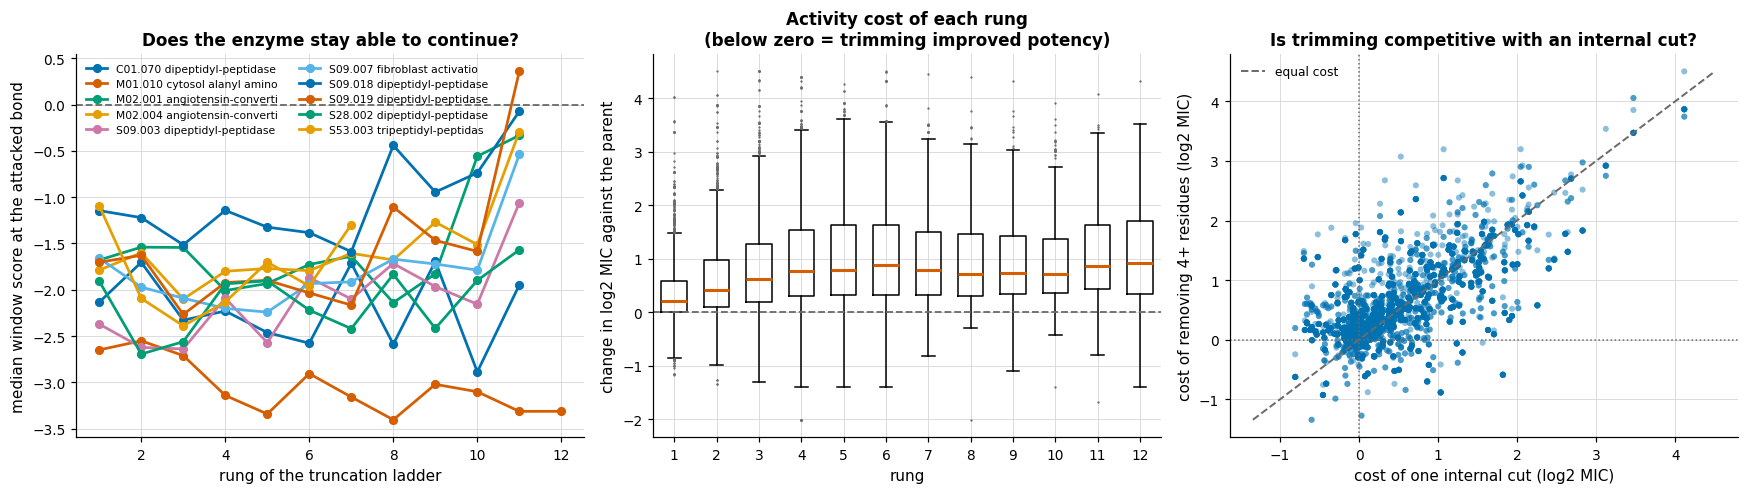

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6))

ax = axes[0]
for index, (code, group) in enumerate(by_rung.groupby("merops_code")):
    group = group.sort_values("rung")
    ax.plot(
        group["rung"],
        group["median_score"],
        marker="o",
        markersize=5,
        linewidth=1.8,
        color=common.CATEGORICAL_COLORS[index % len(common.CATEGORICAL_COLORS)],
        label=f"{code} {group['name'].iloc[0][:20]}",
    )
ax.axhline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.2)
ax.set_xlabel("rung of the truncation ladder")
ax.set_ylabel("median window score at the attacked bond")
ax.set_title("Does the enzyme stay able to continue?")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
positions = sorted(with_mic["rung"].unique())
ax.boxplot(
    [with_mic.query("rung == @rung")["log2_mic_change"] for rung in positions],
    positions=positions,
    widths=0.6,
    medianprops={"color": common.CATEGORICAL_COLORS[1], "linewidth": 2},
    flierprops={"marker": ".", "markersize": 3, "markerfacecolor": common.NEUTRAL, "markeredgecolor": "none"},
)
ax.axhline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.2)
ax.set_xlabel("rung")
ax.set_ylabel("change in log2 MIC against the parent")
ax.set_title("Activity cost of each rung\n(below zero = trimming improved potency)")

ax = axes[2]
ax.scatter(
    comparison["internal_log2_mic_change"],
    comparison["trimming_log2_mic_change"],
    s=16,
    alpha=0.45,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="none",
)
limits = [
    min(comparison["internal_log2_mic_change"].min(), comparison["trimming_log2_mic_change"].min()),
    max(comparison["internal_log2_mic_change"].max(), comparison["trimming_log2_mic_change"].max()),
]
ax.plot(limits, limits, color=common.NEUTRAL, linestyle="--", linewidth=1.3, label="equal cost")
ax.axhline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.axvline(0.0, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xlabel("cost of one internal cut (log2 MIC)")
ax.set_ylabel(f"cost of removing {MATCHED_RESIDUES_REMOVED}+ residues (log2 MIC)")
ax.set_title("Is trimming competitive with an internal cut?")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Provenance**

The protease selection and `event_geometry` come from `results/2_07_model_panel.csv`; MEROPS 2023 score profiles come from `data/merops/34_homo_sapiens/matrices_logprob.npy`. The left panel aggregates model scores by protease and rung, the middle panel uses the simulated rungs with a fragment MIC lookup, and the right panel pairs trimming with one internal cut for a common parent and protease. The output `results/1_02_exopeptidase_processivity.csv` summarizes by MEROPS code; code cells 8–18 define the ladder and comparisons. No plotted observation is an in-serum cleavage time or a measured fragment MIC.


## Result

One row per exopeptidase, with how far its ladder descends, how its rate
evolves and what the ladder costs relative to a single internal cut. The table
is what `4_` uses to decide whether the exopeptidase channel needs the full
Markov ladder or can be truncated after a fixed number of rungs.

In [11]:
result = ladder_summary.merge(
    comparison.groupby("merops_code")
    .agg(
        peptides_compared=("parent", "nunique"),
        median_rungs_to_matched_loss=("rung", "median"),
        median_trimming_log2_mic=("trimming_log2_mic_change", "median"),
        median_internal_log2_mic=("internal_log2_mic_change", "median"),
        share_trimming_cheaper=("trimming_costs_less", "mean"),
    )
    .reset_index(),
    on="merops_code",
    how="left",
)
result = result.merge(
    exopeptidases[["merops_code", "abundance_pg_per_l", "validation_tier"]],
    on="merops_code",
    how="left",
)
destination = common.save_result(result, "1_02_exopeptidase_processivity.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
result.round(3)

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/1_02_exopeptidase_processivity.csv


,merops_code,name,event_geometry,max_rung,score_at_first_rung,score_at_last_rung,score_drop_along_ladder,peptides_compared,median_rungs_to_matched_loss,median_trimming_log2_mic,median_internal_log2_mic,share_trimming_cheaper,abundance_pg_per_l,validation_tier
0,S53.003,tripeptidyl-peptidase I,tripeptidyl_peptidase,7,-1.094,-1.296,0.201,400,2.0,0.628,0.359,0.250,4500000.0,assumed
1,S09.018,dipeptidyl-peptidase 8,dipeptidyl_peptidase,11,-1.146,-0.073,-1.072,400,2.0,0.421,0.359,0.378,NaN,assumed
2,S09.007,fibroblast activation protein alpha subunit,dipeptidyl_peptidase,11,-1.659,-0.539,-1.120,400,2.0,0.421,0.359,0.378,110000000.0,assumed
3,M02.001,angiotensin-converting enzyme peptidase unit 1,peptidyl_dipeptidase,11,-1.679,-0.333,-1.346,400,2.0,0.401,0.359,0.418,87000000.0,assumed
4,S09.019,dipeptidyl-peptidase 9,dipeptidyl_peptidase,11,-1.703,0.358,-2.061,400,2.0,0.421,0.359,0.378,44000.0,supported
5,M02.004,angiotensin-converting enzyme peptidase unit 2,peptidyl_dipeptidase,11,-1.788,-0.293,-1.495,400,2.0,0.401,0.359,0.418,87000000.0,assumed
6,S28.002,dipeptidyl-peptidase II,dipeptidyl_peptidase,11,-1.908,-1.569,-0.338,400,2.0,0.421,0.359,0.378,2000000.0,assumed
7,C01.070,dipeptidyl-peptidase I,dipeptidyl_peptidase,11,-2.134,-1.949,-0.186,400,2.0,0.421,0.359,0.378,12000000.0,assumed
8,S09.003,dipeptidyl-peptidase IV (eukaryote),dipeptidyl_peptidase,11,-2.372,-1.061,-1.311,400,2.0,0.421,0.359,0.378,640000000.0,supported
9,M01.010,cytosol alanyl aminopeptidase,aminopeptidase,12,-2.650,-3.313,0.663,400,4.0,0.421,0.359,0.378,4300000.0,assumed
